# AMPK model development: Tests of AXP regulatory equations
#### Note: These equations are adapted from Allen's work in mito_cyto.cps

The following first-order AXP regulatory model will be explored:

**Hydrolysis of ATP**
$$
    ATP \to ADP 

$$
with flux $J_{\rm hydro} = k_{\rm f, hydro}[ATP]$.

**Glycolysis**
$$
    Glucose + ADP \to ATP + Pyruvate
$$
with flux $J_{\rm Gly} = k_{\rm f, Gly}[ADP][Glucose]$.

**Adenylate kinase**
$$
    2ADP \rightleftharpoons AMP + ATP
$$
with flux $J_{\rm ADK} = k_{\rm f, ADK}[ADP]^2 - k_{\rm r, ADK}[AMP][ATP]$.

**Basal ATP production**
$$
    ADP \to ATP
$$
with flux $J_{\rm Batp} = k_{\rm f,Batp}[ADP]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline

Define a function for the ODEs corresponding to the above reactions.

Let the state vector $\mathbf{x}(t)$ be defined as
$$
    \mathbf{x}(t) = \left[[AMP], [ADP], [ATP]\right]^\top,
$$
where $x_i(t)$ is the $i{\rm th}$ entry of $\mathbf{x}(t)$. Further let the parameter vector $\mathbf{p}$ be defined as
$$
    \mathbf{p} = \left[k_{\rm f, hydro}, k_{\rm f, Gly}, k_{\rm f, ADK}, k_{\rm r, ADK}, k_{\rm f,Batp}, [Glucose]\right]^\top
$$.

In [2]:
def model_eqns(t, x, p):
    # fluxes
    Jhydro = p[0]*x[2]  # atp hydrolysis
    Jgly = p[1]*x[1]*p[5]  # glycolysis
    Jadk = p[2]*x[1]*x[1] - p[3]*x[0]*x[2]  # adenylate kinase
    Jbatp = p[4]*x[1]  # basal ATP prod

    # ode
    dxdt = np.zeros(x.shape)
    dxdt[0] = Jadk  # AMP
    dxdt[1] = Jhydro - 2*Jadk  - Jgly - Jbatp# ADP
    dxdt[2] = Jgly + Jadk + Jbatp - Jhydro  # ATP

    return dxdt

Define initial conditions and parameter values based on Coccimiglio et al. 2020 and Allen's model

In [3]:
k_f_hydro = 0.05
k_f_gly = 0.004981616349
k_f_adk = 0.1  # 4.956757333e-06
k_r_adk = 0.1  # 9.243088491e-06
k_f_batp = 0.1
glucose = 1.0

amp_ic = 10
adp_ic = 212.4164304
atp_ic = 8999.982011

x0 = np.array([amp_ic, adp_ic, atp_ic])
p = np.array([k_f_hydro, k_f_gly, k_f_adk, k_r_adk, k_f_batp, glucose])

Text(0, 0.5, 'Species concentration $\\mu$mol')

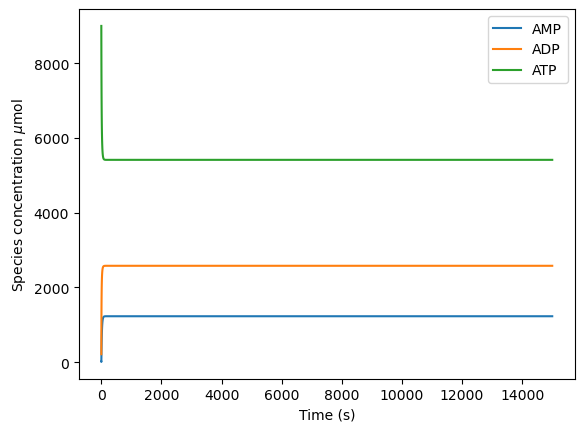

In [4]:
tspan = (0, 15000)
x_sol = solve_ivp(model_eqns, tspan, x0, args=([p]), method='BDF')
x_steady_state = x_sol.y[:, -1]

fig, ax = plt.subplots()
ax.plot(x_sol.t, x_sol.y[0])
ax.plot(x_sol.t, x_sol.y[1])
ax.plot(x_sol.t, x_sol.y[2])
ax.legend(['AMP', 'ADP', 'ATP'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Species concentration $\mu$mol')

Now, perturb glucose concentration and simulate from the new steady state.

Text(0.5, 1.0, 'Response to reduction in Glucose concentration')

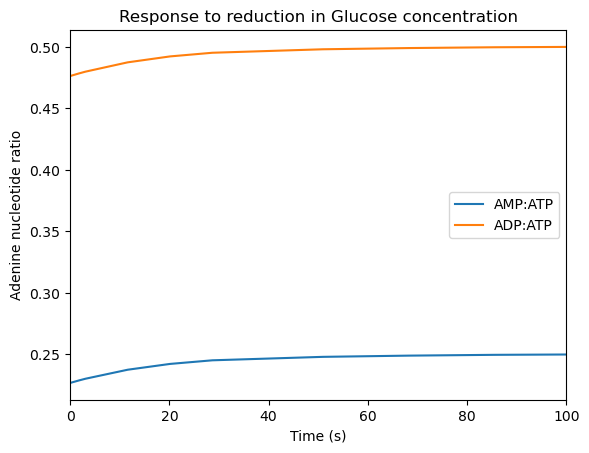

In [14]:
glucose_pertubed = 0.0
p = np.array([k_f_hydro, k_f_gly, k_f_adk, k_r_adk, k_f_batp, glucose_pertubed])   
tspan = (0, 100)

x_sol_pertubed = solve_ivp(model_eqns, tspan, x_steady_state, args=([p]), method='BDF')

fig, ax = plt.subplots()
# ax.plot(x_sol_pertubed.t, x_sol_pertubed.y[0])
ax.plot(x_sol_pertubed.t, x_sol_pertubed.y[0]/x_sol_pertubed.y[2])
ax.plot(x_sol_pertubed.t, x_sol_pertubed.y[1]/x_sol_pertubed.y[2])
ax.legend(['AMP:ATP', 'ADP:ATP'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Adenine nucleotide ratio')
ax.set_xlim([0, 100])
ax.set_title('Response to reduction in Glucose concentration')